In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report


Exploring training data...
Training shape: (3823, 65)
Number of training missing values: 0
Sample training row (10 values): [0, 1, 6, 15, 12, 1, 0, 0, 0, 7] ...

Pixel intensity counts (0-16):
Intensity 0: 119391 samples
Intensity 1: 8397 samples
Intensity 2: 7055 samples
Intensity 3: 6148 samples
Intensity 4: 6908 samples
Intensity 5: 5858 samples
Intensity 6: 5570 samples
Intensity 7: 5599 samples
Intensity 8: 7574 samples
Intensity 9: 5523 samples
Intensity 10: 5694 samples
Intensity 11: 5889 samples
Intensity 12: 8078 samples
Intensity 13: 7218 samples
Intensity 14: 7846 samples
Intensity 15: 9144 samples
Intensity 16: 22780 samples


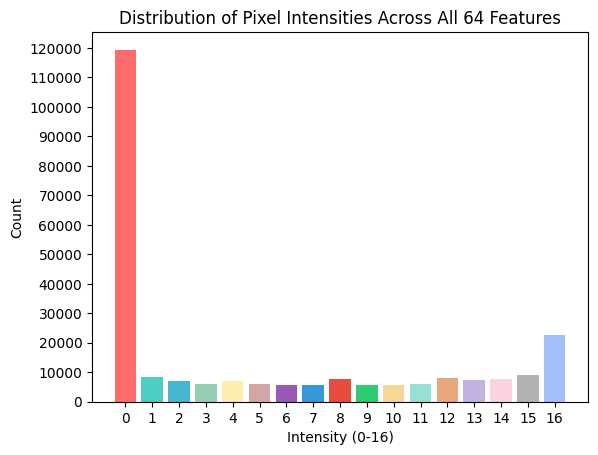

,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,64
count,3823.0,3823.000000,3823.000000,3823.000000,3823.000000,3823.000000,3823.000000,3823.000000,3823.000000,3823.000000,...,3823.000000,3823.000000,3823.000000,3823.000000,3823.000000,3823.000000,3823.000000,3823.000000,3823.000000,3823.000000
mean,0.0,0.301334,5.481821,11.805912,11.451478,5.505362,1.387392,0.142297,0.002093,1.960502,...,0.148313,0.000262,0.283024,5.855872,11.942977,11.461156,6.700497,2.105676,0.202197,4.497253
std,0.0,0.866986,4.631601,4.259811,4.537556,5.613060,3.371444,1.051598,0.088572,3.052353,...,0.767761,0.016173,0.928046,4.980012,4.334508,4.991934,5.775815,4.028266,1.150694,2.869831
min,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.0,0.000000,1.000000,10.000000,9.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,10.000000,9.000000,0.000000,0.000000,0.000000,2.000000
50%,0.0,0.000000,5.000000,13.000000,13.000000,4.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,5.000000,13.000000,13.000000,6.000000,0.000000,0.000000,4.000000
75%,0.0,0.000000,9.000000,15.000000,15.000000,10.000000,0.000000,0.000000,0.000000,3.000000,...,0.000000,0.000000,0.000000,10.000000,15.000000,16.000000,12.000000,2.000000,0.000000,7.000000
max,0.0,8.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,5.000000,15.000000,...,12.000000,1.000000,10.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,9.000000


In [10]:
# 1. Load and explore the data. (10 points)
# Load training data from optdigits.tra file.
train_data = pd.read_csv('optdigits.tra', sep=',', header=None)

print("Exploring training data...")
print("Training shape:", train_data.shape)  # Should be (3823, 65)
print("Number of training missing values:", train_data.isnull().sum().sum())
train_data = train_data.dropna()
print("Sample training row (10 values):", train_data.iloc[0].tolist()[:10], "...")

# Use a loop to count values 0-16 across 64 features.
intensity_counts = np.zeros(17, dtype=int)  # Array for intensities 0-16
for index, row in train_data.iterrows():
    for value in row.iloc[:-1]:  # Exclude the last column (label)
        if 0 <= value <= 16:  # Ensure values are within 0-16 range
            intensity_counts[value] += 1

print("\nPixel intensity counts (0-16):")
for i, count in enumerate(intensity_counts):
    print(f"Intensity {i}: {count} samples")

# Bar chart for 0-16 pixel intensity distribution across 64 features.
intensities = range(17)
plt.bar(intensities, intensity_counts, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEEAD', '#D4A5A5', '#9B59B6', '#3498DB', '#E74C3C', '#2ECC71', '#F7D794', '#95E1D3', '#E8A87C', '#C3B1E1', '#FAD2E1', '#B2B2B2', '#A3BFFA'])
plt.xlabel('Intensity (0-16)')
plt.xticks(np.arange(0, 17, 1))
plt.ylabel('Count')
plt.yticks(np.arange(0, 120001, 10000))
plt.title('Distribution of Pixel Intensities Across All 64 Features')
plt.show()

# Generate descriptive statistics for pixel intensity across all 65 features.
train_data.describe()


The training dataset contained predominantly zero values for pixel intensity.  Feature 0 has only zero values.  There looks to be more than 5,500 samples for 0-9 pixel intensities, which should be sufficient to train the models.  The label feature 64 was omitted from the count summaries, given it contains the relevant 0-9 labels and will be used as the y value in the models.


Exploring validation data...
Validation shape: (1797, 65)
Number of validation missing values: 0
Sample vaildation row (10 values): [0, 0, 5, 13, 9, 1, 0, 0, 0, 0] ...

Pixel intensity counts (0-16):
Intensity 0: 56272 samples
Intensity 1: 4095 samples
Intensity 2: 3296 samples
Intensity 3: 2944 samples
Intensity 4: 3261 samples
Intensity 5: 2803 samples
Intensity 6: 2559 samples
Intensity 7: 2627 samples
Intensity 8: 3464 samples
Intensity 9: 2585 samples
Intensity 10: 2711 samples
Intensity 11: 2845 samples
Intensity 12: 3668 samples
Intensity 13: 3509 samples
Intensity 14: 3609 samples
Intensity 15: 4304 samples
Intensity 16: 10456 samples


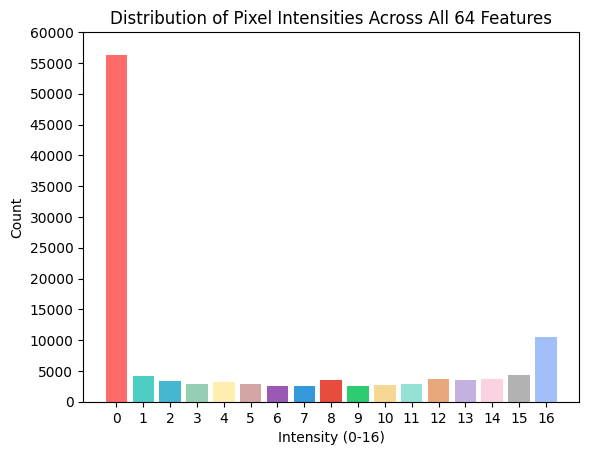

,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,64
count,3823.0,3823.000000,3823.000000,3823.000000,3823.000000,3823.000000,3823.000000,3823.000000,3823.000000,3823.000000,...,3823.000000,3823.000000,3823.000000,3823.000000,3823.000000,3823.000000,3823.000000,3823.000000,3823.000000,3823.000000
mean,0.0,0.301334,5.481821,11.805912,11.451478,5.505362,1.387392,0.142297,0.002093,1.960502,...,0.148313,0.000262,0.283024,5.855872,11.942977,11.461156,6.700497,2.105676,0.202197,4.497253
std,0.0,0.866986,4.631601,4.259811,4.537556,5.613060,3.371444,1.051598,0.088572,3.052353,...,0.767761,0.016173,0.928046,4.980012,4.334508,4.991934,5.775815,4.028266,1.150694,2.869831
min,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.0,0.000000,1.000000,10.000000,9.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,10.000000,9.000000,0.000000,0.000000,0.000000,2.000000
50%,0.0,0.000000,5.000000,13.000000,13.000000,4.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,5.000000,13.000000,13.000000,6.000000,0.000000,0.000000,4.000000
75%,0.0,0.000000,9.000000,15.000000,15.000000,10.000000,0.000000,0.000000,0.000000,3.000000,...,0.000000,0.000000,0.000000,10.000000,15.000000,16.000000,12.000000,2.000000,0.000000,7.000000
max,0.0,8.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,5.000000,15.000000,...,12.000000,1.000000,10.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,9.000000


In [11]:
# Load validation data from optdigits.tes file.
val_data = pd.read_csv('optdigits.tes', sep=',', header=None)

print("\nExploring validation data...")
print("Validation shape:", val_data.shape)  # Should be (1797, 65)
print("Number of validation missing values:", val_data.isnull().sum().sum())
val_data = val_data.dropna()
print("Sample vaildation row (10 values):", val_data.iloc[0].tolist()[:10], "...")

# Use a loop to count values 0-16 across 64 festures.
intensity_counts = np.zeros(17, dtype=int)  # Array for intensities 0-16
for index, row in val_data.iterrows():
    for value in row.iloc[:-1]:  # Exclude the last column (label)
        if 0 <= value <= 16:  # Ensure values are within 0-16 range
            intensity_counts[value] += 1

print("\nPixel intensity counts (0-16):")
for i, count in enumerate(intensity_counts):
    print(f"Intensity {i}: {count} samples")

# Bar chart for 0-16 pixel intensity distribution across 64 features.
intensities = range(17)
plt.bar(intensities, intensity_counts, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEEAD', '#D4A5A5', '#9B59B6', '#3498DB', '#E74C3C', '#2ECC71', '#F7D794', '#95E1D3', '#E8A87C', '#C3B1E1', '#FAD2E1', '#B2B2B2', '#A3BFFA'])
plt.xlabel('Intensity (0-16)')
plt.xticks(np.arange(0, 17, 1))
plt.ylabel('Count')
plt.yticks(np.arange(0, 60001, 5000))
plt.title('Distribution of Pixel Intensities Across All 64 Features')
plt.show()

# Generate descriptive statistics for pixel intensity across all 65 features.
train_data.describe()


The validation dataset contained predominantly zero values for pixel intensity.  Feature 0 has only zero values.  There looks to be more than 2,550 samples for 0-9 pixel intensities, which should be sufficient to validate and tune the models.  The label feature 64 was omitted from the count summaries, given it contains the relevant 0-9 labels and will be used as the y value in the models.

In [12]:
# Load testing data from load_digits.
digits = load_digits()

print("\nExploring test data...")
print("Testing shape:", digits.data.shape)  # Should be (1797, 64)
print("Number of classes:", len(np.unique(digits.target)))  # Should be 10
print("Unique testing labels:", np.unique(digits.target))



Exploring test data...
Testing shape: (1797, 64)
Number of classes: 10
Unique testing labels: [0 1 2 3 4 5 6 7 8 9]


In [13]:
# 2. Split the data for training, validation, and testing. (10 points)
X_train = train_data.iloc[:, :-1].values  # 64 features
y_train = train_data.iloc[:, -1].values

X_val = val_data.iloc[:, :-1].values  # 64 features
y_val = val_data.iloc[:, -1].values

X_test = digits.data
y_test = digits.target


For the training data, features 0-63 were used for X_train, and feature 64 was used for y_train.  For the validation data, features 0-63 were used for X_val, and feature 64 was used for y_val.  For the testing data, the sklearn load_digits data were used for X_test, and load_digits target values (0-9) were used for y_test.

In [14]:
# 3. Select and build the model. (10 points)
models = {
    'KNeighborsClassifier': KNeighborsClassifier(),
    'SVC': SVC(),
    'GaussianNB': GaussianNB()
}


The three required classification models were defined.

In [15]:
# 4. Train the model. (10 points)
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)



Training KNeighborsClassifier...

Training SVC...

Training GaussianNB...


The training data was used to train the models.

In [16]:
# 5. Make predictions. (10 points)
predictions_val = {}  # For validation
for name, model in models.items():
    predictions_val[name] = model.predict(X_val)


The validation data was used to make initial model predictions.

In [17]:
# 6. Evaluate the result. (10 points)
print("\nInitial evaluation on optdigits.tes (validation):")
for name, pred in predictions_val.items():
    print(f"\n{name}:")
    print(classification_report(y_val, pred))

# Use model accuracy to determine the best model.
best_accuracy = 0
best_model_name = ""
for name, pred in predictions_val.items():
    accuracy = np.mean(pred == y_val)
    print(f"\nAccuracy for {name} on optdigits.tes (validation): {accuracy:.4f}")
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model_name = name

print(f"\nThe best model on optdigits.tes (validation) was {best_model_name} with an accuracy of {best_accuracy:.4f}")



Initial evaluation on optdigits.tes (validation):

KNeighborsClassifier:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       178
           1       0.93      0.99      0.96       182
           2       0.99      0.98      0.99       177
           3       0.98      0.97      0.98       183
           4       0.99      0.99      0.99       181
           5       0.98      0.99      0.98       182
           6       0.99      0.99      0.99       181
           7       0.99      0.97      0.98       179
           8       0.97      0.93      0.95       174
           9       0.96      0.97      0.96       180

    accuracy                           0.98      1797
   macro avg       0.98      0.98      0.98      1797
weighted avg       0.98      0.98      0.98      1797


SVC:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       178
           1       0.95      0.99      0.97       18

The KNeighborsClassifier and SVC methods perfomed well with an accuracy of greater than 0.975 on the validation data.  The GaussianNB method with an accuracy of 0.7863 may not be capturing enough variation in the validation data.  When looking at all three model classification matrices, it is not surprising that 0 seem to garner the best f1-scores (1.00, 1.00, 0.94).  It is interesting that 8 and 9 had the lower f1-scores (0.95, 0.95, 0.64), but possibly makes sense that those handwritten numbers could be more easily confused with other numbers.

In [48]:
# 7. Tune the model. (10 points)
param_grids = {
    'KNeighborsClassifier': {'n_neighbors': [3, 5, 7, 9], 'weights': ['uniform', 'distance'], 'metric': ['euclidean', 'manhattan'], 'algorithm': ['auto', 'kd_tree']},
    'SVC': {'C': [5, 6, 7], 'gamma': ['scale', 'auto'], 'kernel': ['rbf', 'linear'], 'class_weight': [None, 'balanced']}, # Started with [1, 5, 10] for C, and eventually tuned to 6
    'GaussianNB': {'var_smoothing': [0.07, 0.08, 0.09]} # Started with [1e-9, 1e-7, 1e-5] for var_smoothing, and eventually tuned to 0.08
}

tuned_models = {}
for name, model in models.items():
    print(f"\nTuning {name} on optdigits.tes (validation)...")
    grid = GridSearchCV(model, param_grids[name], cv=5, scoring='accuracy')
    grid.fit(X_train, y_train)  # Train on optdigits.tra file, validate on optdigits.tes file
    tuned_models[name] = grid.best_estimator_
    print(f"Best parameters for {name}: {grid.best_params_}")



Tuning KNeighborsClassifier on optdigits.tes (validation)...
Best parameters for KNeighborsClassifier: {'algorithm': 'auto', 'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'distance'}

Tuning SVC on optdigits.tes (validation)...
Best parameters for SVC: {'C': 6, 'class_weight': None, 'gamma': 'scale', 'kernel': 'rbf'}

Tuning GaussianNB on optdigits.tes (validation)...
Best parameters for GaussianNB: {'var_smoothing': 0.08}


The training and validation data were used to tune the models.  The tuning process uses GridSearchCV to test multiple parameter combinations and selects the best based on 5-fold cross-validation accuracy. Regarding the KNeighborsClassifier parameter results, the 'n_neighbors': 7 suggests a moderate number of neighbors, balancing local fit and generalization. This is reasonable for digit recognition where 7 neighbors can capture local patterns without overfitting to noise. The 'weights': 'distance' means that closer neighbors contribute more, which is appropriate for image data where proximity in feature space (pixel intensities) should correlate with class similarity.  The 'metric': 'euclidean' is a standard choice for continuous feature spaces like pixel values, aligning well with the 64-feature input. The 'algorithm': 'auto' lets scikit-learn choose the best algorithm based on the data, which is efficient and default-safe.

Regarding the SVC parameter results, the 'C': 6 is a moderate value offering some flexibility in margin, while identifying misclassification by penalizing errors.  The 'class_weight': None means no class balancing, which is fine if the digit classes (0-9) are evenly distributed in the validation data.  The 'gamma': 'scale' (default for RBF) adjusts the kernel width based on feature variance, suitable for the 64-feature dimensional pixel data.  The 'kernel': 'rbf' (radial basis function) is a non-linear kernel, ideal for capturing complex decision boundaries in image data.

Regarding the GaussianNB parameter result, the 'var_smoothing': 0.08 adds a small variance to prevent numerical instability, a common adjustment for naive Bayes on continuous data like pixel intensities.  Of all three models, the GaussianNB model showed the most improvement through tuning (0.7863 to 0.9054).  The KNeighborsClassifier model marginally lost some accuracy through tuning(0.9789 to 0.9777), but likely reduced overfitting.  The SVC model marginally gained some accuracy through tuning (0.9761 to 0.9811).  Tuned validation data accuracy results were not provided, because they matched the following tuned testing data accuracy results.  The optdigits.tes file must have been created from the load_digits data.

In [49]:
# 8. Run several classification models to choose the best one. (30 points)

# Run the tuned models to predict on the load_digits testing data set.
predictions_test = {}
for name, model in tuned_models.items():
    print(f"\nRunning the {name} model with tuned parameters on load_digits (testing):")
    model.fit(X_train, y_train)
    predictions_test[name] = model.predict(X_test)
    print(classification_report(y_test, predictions_test[name]))

# Use model accuracy to determine the best model.
best_accuracy = 0
best_model_name = ""
for name, pred in predictions_test.items():
    accuracy = np.mean(pred == y_test)
    print(f"\nAccuracy for {name} on load_digits (testing): {accuracy:.4f}")
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model_name = name

print(f"\nThe best model on load_digits (testing) was {best_model_name} with an accuracy of {best_accuracy:.4f}")


Running the KNeighborsClassifier model with tuned parameters on load_digits (testing):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       178
           1       0.91      0.99      0.95       182
           2       1.00      0.98      0.99       177
           3       0.98      0.97      0.98       183
           4       0.99      0.98      0.99       181
           5       0.99      0.98      0.99       182
           6       0.99      1.00      1.00       181
           7       0.99      0.98      0.99       179
           8       0.96      0.92      0.94       174
           9       0.96      0.97      0.96       180

    accuracy                           0.98      1797
   macro avg       0.98      0.98      0.98      1797
weighted avg       0.98      0.98      0.98      1797


Running the SVC model with tuned parameters on load_digits (testing):
              precision    recall  f1-score   support

           0       0.99    

The KNeighborsClassifier and SVC methods perfomed well with an accuracy of greater than 0.975 on the testing data.  After tuning, the GaussianNB method improved to an accuracy of 0.9054 on the testing data.  Collectively looking at all three model classifcation matrices, 0 and 6 seem to garner the best f1-scores (1.00, 1.00, 0.97), and 8 had the lowest f1-scores (0.94, 0.96, 0.82).  Interestingly enough, 1 had the lowest f1-score (0.80) for the GaussianNB method.  The tuned SVC model generated the highest accuracy of 0.9811 on the testing data.